# Phase 3

# CELL 1  -  Imports

In [1]:
import sys, io

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from itertools import combinations

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint, CSVLogger)

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("[OK] TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print(f"[OK] GPUs available: {len(gpus)}")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"[OK] GPU memory growth enabled for {len(gpus)} GPU(s).")
else:
    print("[WARN] No GPU! Enable GPU: Kaggle Settings -> Accelerator -> GPU P100.")


2026-06-28 06:18:20.431508: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782627500.616427      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782627500.667271      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782627501.122682      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782627501.122722      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782627501.122724      58 computation_placer.cc:177] computation placer alr

[OK] TensorFlow version: 2.19.0
[OK] GPUs available: 1
[OK] GPU memory growth enabled for 1 GPU(s).


# CELL 2  -  Configuration

## To find path of Phase 1+2 notebook output

In [2]:
# Run this to find the exact path inside /kaggle/input/notebooks/
import os
from pathlib import Path

print("=== Searching for phase1_outputs ===\n")

# Search 3 levels deep under /kaggle/input/
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.replace("/kaggle/input", "").count(os.sep)
    if depth > 3:
        continue  # don't go too deep
    indent = "  " * depth
    print(f"{indent}{root}/")
    if "phase1_outputs" in dirs:
        full_path = Path(root) / "phase1_outputs"
        print(f"\n{'='*50}")
        print(f"  FOUND: {full_path}")
        print(f"  Use this in Cell 2:")
        print(f"  PHASE12_INPUT = Path(\"{full_path}\")")
        print(f"{'='*50}\n")

=== Searching for phase1_outputs ===

/kaggle/input/
  /kaggle/input/datasets/
    /kaggle/input/datasets/kmader/
      /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/
  /kaggle/input/notebooks/
    /kaggle/input/notebooks/bobbi12235/
      /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/

  FOUND: /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs
  Use this in Cell 2:
  PHASE12_INPUT = Path("/kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs")



In [3]:
# CELL 2 — Configuration for Phase 3 standalone notebook
import os, json
from pathlib import Path

# ── HAM10000 real images ──────────────────────────────────────────────────
HAM10000_INPUT = Path("/kaggle/input/skin-cancer-mnist-ham10000")

# ── Phase 1+2 preprocessed outputs ───────────────────────────────────────
# Kaggle mounts added datasets at /kaggle/input/[dataset-slug]/
PHASE12_INPUT = Path("/kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs")

# Verify the Phase12 dataset is mounted
if not PHASE12_INPUT.exists():
    raise FileNotFoundError(
        f"Phase 1+2 dataset not found at {PHASE12_INPUT}\n"
        "Add 'melanoscan-phase12-outputs' as an input dataset to this notebook:\n"
        "  Notebook Settings (right panel) → Add Data → Your Datasets → melanoscan-phase12-outputs"
    )

# ── Output paths for this notebook ───────────────────────────────────────
OUTPUT_DIR  = Path("/kaggle/working/phase3_outputs")
MODELS_DIR  = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"
SPLITS_DIR  = PHASE12_INPUT / "splits"    # read from Phase12 dataset

for d in [OUTPUT_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Model config ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
N_CLASSES   = 7
BATCH_SIZE  = 32
EPOCHS      = 40
LR_INIT     = 1e-3
LR_FINETUNE = 1e-5
SEED        = 42

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_LABELS = {
    "akiec": "Actinic Keratoses", "bcc": "Basal Cell Carcinoma",
    "bkl"  : "Benign Keratosis",  "df" : "Dermatofibroma",
    "mel"  : "Melanoma",          "nv" : "Melanocytic Nevi",
    "vasc" : "Vascular Lesions"
}
dx_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

print("[OK] Configuration complete.")
print(f"  Phase12 dataset : {PHASE12_INPUT}")
print(f"  Model outputs   : {MODELS_DIR}")
print(f"  Classes         : {CLASS_NAMES}")

[OK] Configuration complete.
  Phase12 dataset : /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs
  Model outputs   : /kaggle/working/phase3_outputs/models
  Classes         : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


# CELL 3  -  Load Splits

In [4]:
# CELL 3 — Load Splits with automatic path remapping
import pandas as pd

def remap_image_paths(df, phase12_input_path):
    """
    The augmented CSV was built in Notebook 1 where synthetic images lived at:
      /kaggle/working/phase1_outputs/synthetic_images/...
    In this notebook they are mounted at:
      /kaggle/input/melanoscan-phase12-outputs/phase1_outputs/synthetic_images/...
    This function remaps all synthetic paths. Real HAM10000 paths are unchanged.
    """
    OLD_BASE = "/kaggle/working/phase1_outputs"
    NEW_BASE = str(phase12_input_path)

    if "image_path" in df.columns:
        n_before = df["image_path"].str.startswith(OLD_BASE).sum()
        df["image_path"] = df["image_path"].str.replace(
            OLD_BASE, NEW_BASE, regex=False
        )
        if n_before > 0:
            print(f"  Remapped {n_before:,} synthetic image paths")
    return df

# Load real-image splits (paths already point to /kaggle/input/skin-cancer-mnist-ham10000/...)
df_train_baseline = pd.read_csv(SPLITS_DIR / "train_split.csv")
df_train_v1       = pd.read_csv(SPLITS_DIR / "train_split.csv")
df_val            = pd.read_csv(SPLITS_DIR / "val_split.csv")
df_test           = pd.read_csv(SPLITS_DIR / "test_split.csv")

# Load augmented CSV (contains synthetic paths that need remapping)
aug_path = SPLITS_DIR / "train_split_augmented_v2.csv"
if aug_path.exists():
    df_train_v2 = pd.read_csv(aug_path)
    print("Remapping synthetic image paths in augmented dataset...")
    df_train_v2 = remap_image_paths(df_train_v2, PHASE12_INPUT)
    print(f"  [OK] Augmented dataset: {len(df_train_v2):,} samples")
else:
    print("[WARN] Augmented CSV not found — Model C will use original training data.")
    df_train_v2 = pd.read_csv(SPLITS_DIR / "train_split.csv")

# Encode labels
for df in [df_train_baseline, df_train_v1, df_train_v2, df_val, df_test]:
    df["label"] = df["dx"].map(dx_to_idx)

# Quick sanity check — verify a sample of images actually exist
import random
sample = random.sample(df_train_v2["image_path"].tolist(), min(5, len(df_train_v2)))
missing = [p for p in sample if not Path(p).exists()]
if missing:
    print(f"[WARN] {len(missing)} sampled image paths do not exist. Check dataset mounting.")
    for p in missing:
        print(f"  MISSING: {p}")
else:
    print("  [OK] Sampled image paths verified — all exist.")

print(f"\nModel A train : {len(df_train_baseline):,}")
print(f"Model B train : {len(df_train_v1):,}")
print(f"Model C train : {len(df_train_v2):,}")
print(f"Val           : {len(df_val):,}")
print(f"Test          : {len(df_test):,}")

Remapping synthetic image paths in augmented dataset...
  Remapped 3,660 synthetic image paths
  [OK] Augmented dataset: 10,670 samples
  [OK] Sampled image paths verified — all exist.

Model A train : 7,010
Model B train : 7,010
Model C train : 10,670
Val           : 1,474
Test          : 1,474


# CELL 4  -  tf.data Pipeline

In [5]:
# CELL 4  -  tf.data Pipeline (FIXED)
from sklearn.utils.class_weight import compute_class_weight

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_dataset(df, shuffle=False, augment_flag=False, batch_size=BATCH_SIZE):
    """Build tf.data.Dataset — returns (image, label) pairs only.
    Class weighting is handled via class_weight in model.fit(), not in the dataset.
    """
    paths  = df["image_path"].tolist()
    labels = df["label"].tolist()

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)

    if augment_flag:
        dataset = dataset.map(augment_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(df), 4096), seed=SEED)

    dataset = dataset.batch(batch_size).prefetch(AUTOTUNE)
    return dataset

def get_class_weights(df):
    """Compute balanced class weights to counter nv class dominance (67%).
    Returns dict {class_index: weight} for use with model.fit(class_weight=...)
    """
    labels  = df["label"].values
    classes = np.unique(labels)
    weights = compute_class_weight("balanced", classes=classes, y=labels)
    cw = dict(zip(classes.tolist(), weights.tolist()))
    print(f"  Class weights: { {CLASS_NAMES[k]: round(v,3) for k,v in cw.items()} }")
    return cw

val_ds  = build_dataset(df_val,  shuffle=False, augment_flag=False)
test_ds = build_dataset(df_test, shuffle=False, augment_flag=False)

print("[OK] Evaluation datasets built.")

[OK] Evaluation datasets built.


I0000 00:00:1782627531.526701      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# CELL 5  -  Model Architecture (EfficientNet-B0 + Custom Head)

In [6]:
def build_model(n_classes=N_CLASSES, dropout_rate=0.4):
    """
    EfficientNet-B0 as feature extractor (pretrained on ImageNet).
    Custom classification head:  GlobalAvgPool -> Dropout -> Dense(256) -> Dense(N_CLASSES)
    Returns: compiled Keras model
    """
    # Input layer
    inputs = keras.Input(shape=IMG_SHAPE)

    # Rescale [0,1] -> [-1,1] as expected by EfficientNet
    x = layers.Rescaling(scale=2.0, offset=-1.0)(inputs)

    # Base model  -  frozen initially
    base = EfficientNetB0(include_top=False, weights="imagenet",
                          input_tensor=x, pooling=None)
    base.trainable = False

    # Custom head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_INIT),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base


def get_callbacks(model_name, monitor="val_accuracy"):
    return [
        EarlyStopping(monitor=monitor, patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor=monitor, factor=0.3, patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(str(MODELS_DIR / f"{model_name}_best.h5"),
                        monitor=monitor, save_best_only=True, verbose=0),
        CSVLogger(str(RESULTS_DIR / f"{model_name}_training_log.csv")),
    ]

print("[OK] Model architecture defined (EfficientNet-B0 + custom head).")

[OK] Model architecture defined (EfficientNet-B0 + custom head).


# CELL 6  -  Helper: Two-Phase Training (Freeze -> Unfreeze)

In [7]:
# CELL 6  -  Helper: Two-Phase Training (FIXED — class_weight now applied)
def train_model(model_name, train_df, use_weights=False, augment=True):
    print(f"\n{'='*60}")
    print(f"  TRAINING: {model_name}")
    print(f"{'='*60}")
    print(f"  Training samples : {len(train_df):,}")
    print(f"  Class weighting  : {use_weights}")
    print(f"  Augmentation     : {augment}")

    train_ds = build_dataset(train_df, shuffle=True,
                             augment_flag=augment,
                             batch_size=BATCH_SIZE)

    # ── KEY FIX: compute class weights BEFORE model.fit() ─────────────────
    # class_weight corrects for nv dominating 67% of HAM10000.
    # Without this, all three models collapse to predicting nv for everything,
    # producing identical accuracy (~0.67) and zero melanoma sensitivity.
    class_weight = get_class_weights(train_df) if use_weights else None

    model, base = build_model()

    # Phase 1: Head only (base frozen)
    print(f"\n  [Phase 1] Training head only (base frozen)...")
    h1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight,   # ← FIXED: was missing
        callbacks=get_callbacks(f"{model_name}_phase1"),
        verbose=1
    )

    # Phase 2: Fine-tune top 30 EfficientNet layers
    print(f"\n  [Phase 2] Fine-tuning top 30 layers of EfficientNet-B0...")
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    h2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weight,   # ← FIXED: was missing in phase 2 too
        callbacks=get_callbacks(f"{model_name}_phase2"),
        verbose=1
    )

    model.save(str(MODELS_DIR / f"{model_name}_final.h5"))
    print(f"\n  [OK] {model_name} saved.")

    combined_history = {
        "accuracy"    : h1.history["accuracy"]    + h2.history["accuracy"],
        "val_accuracy": h1.history["val_accuracy"] + h2.history["val_accuracy"],
        "loss"        : h1.history["loss"]         + h2.history["loss"],
        "val_loss"    : h1.history["val_loss"]     + h2.history["val_loss"],
    }
    return model, combined_history

# CELL 7  -  STEP 1.5: Train All Three Models

In [8]:
histories = {}

# - MODEL A: Baseline (original biased dataset, no weights, no augmentation) -
model_a, histories["Model_A_Baseline"] = train_model(
    model_name   = "Model_A_Baseline",
    train_df     = df_train_baseline,
    use_weights  = False,
    augment      = True   # standard augmentation only
)

# - MODEL B: Enhanced v1 (stratified + reweighted, no cGAN) -
model_b, histories["Model_B_Enhanced_v1"] = train_model(
    model_name   = "Model_B_Enhanced_v1",
    train_df     = df_train_v1,
    use_weights  = True,   # <- sample weighting ON
    augment      = True
)

# - MODEL C: Enhanced v2 (stratified + reweighted + cGAN augmented) -
model_c, histories["Model_C_Enhanced_v2"] = train_model(
    model_name   = "Model_C_Enhanced_v2",
    train_df     = df_train_v2,
    use_weights  = True,   # <- sample weighting ON
    augment      = True
)

print("\n[OK] All three models trained successfully.")


  TRAINING: Model_A_Baseline
  Training samples : 7,010
  Class weighting  : False
  Augmentation     : True
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  [Phase 1] Training head only (base frozen)...
Epoch 1/40


I0000 00:00:1782627565.737938     152 service.cc:152] XLA service 0x7c03080513f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782627565.737991     152 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782627568.112057     152 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782627579.900364     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.3614 - loss: 2.0294

220/220 ━━━━━━━━━━━━━━━━━━━━ 90s 207ms/step - accuracy: 0.5004 - loss: 1.6809 - val_accuracy: 0.6771 - val_loss: 1.1750 - learning_rate: 0.0010
Epoch 2/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.6397 - loss: 1.3350 - val_accuracy: 0.6771 - val_loss: 1.1749 - learning_rate: 0.0010
Epoch 3/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.6439 - loss: 1.2901 - val_accuracy: 0.6771 - val_loss: 1.1527 - learning_rate: 0.0010
Epoch 4/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.6499 - loss: 1.2735 - val_accuracy: 0.6771 - val_loss: 1.1504 - learning_rate: 0.0010
Epoch 5/40
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6551 - loss: 1.2523
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.6511 - loss: 1.2611 - val_accuracy: 0.6771 - val_loss: 1.1371 - learning_rate: 0.0010
Epoch 6/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.6595 - loss: 1.2335 

2026-06-28 06:24:28.533723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:24:28.740717: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:24:29.169728: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:24:29.376409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...

334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.2717 - loss: 1.9801 - val_accuracy: 0.6370 - val_loss: 1.7832 - learning_rate: 3.0000e-04
Epoch 15/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.2811 - loss: 1.9817 - val_accuracy: 0.5957 - val_loss: 1.7974 - learning_rate: 3.0000e-04
Epoch 16/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.2737 - loss: 1.9825 - val_accuracy: 0.6316 - val_loss: 1.7986 - learning_rate: 3.0000e-04
Epoch 17/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.2785 - loss: 1.9795 - val_accuracy: 0.5543 - val_loss: 1.8430 - learning_rate: 3.0000e-04
Epoch 18/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2871 - loss: 1.6148
Epoch 18: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
334/334 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.2834 - loss: 1.9695 - val_accuracy: 0.5862 - val_loss: 1.8513 - learning_rate: 3.0000e-04
Epoch 19/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accurac

2026-06-28 06:55:12.145905: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:55:12.351172: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:55:12.731333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:55:12.936987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


334/334 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1991 - loss: 1.6876

334/334 ━━━━━━━━━━━━━━━━━━━━ 90s 145ms/step - accuracy: 0.1891 - loss: 2.0516 - val_accuracy: 0.6764 - val_loss: 1.6023 - learning_rate: 1.0000e-05
Epoch 2/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 33s 63ms/step - accuracy: 0.1897 - loss: 2.0280 - val_accuracy: 0.0495 - val_loss: 2.0155 - learning_rate: 1.0000e-05
Epoch 3/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.1918 - loss: 2.0167 - val_accuracy: 0.0495 - val_loss: 1.9801 - learning_rate: 1.0000e-05
Epoch 4/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.1972 - loss: 2.0105 - val_accuracy: 0.0997 - val_loss: 1.9047 - learning_rate: 1.0000e-05
Epoch 5/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2011 - loss: 1.6406
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.1982 - loss: 2.0088 - val_accuracy: 0.5244 - val_loss: 1.8541 - learning_rate: 1.0000e-05
Epoch 6/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0


  [OK] Model_C_Enhanced_v2 saved.

[OK] All three models trained successfully.


# CELL 8  -  Plot Training Curves

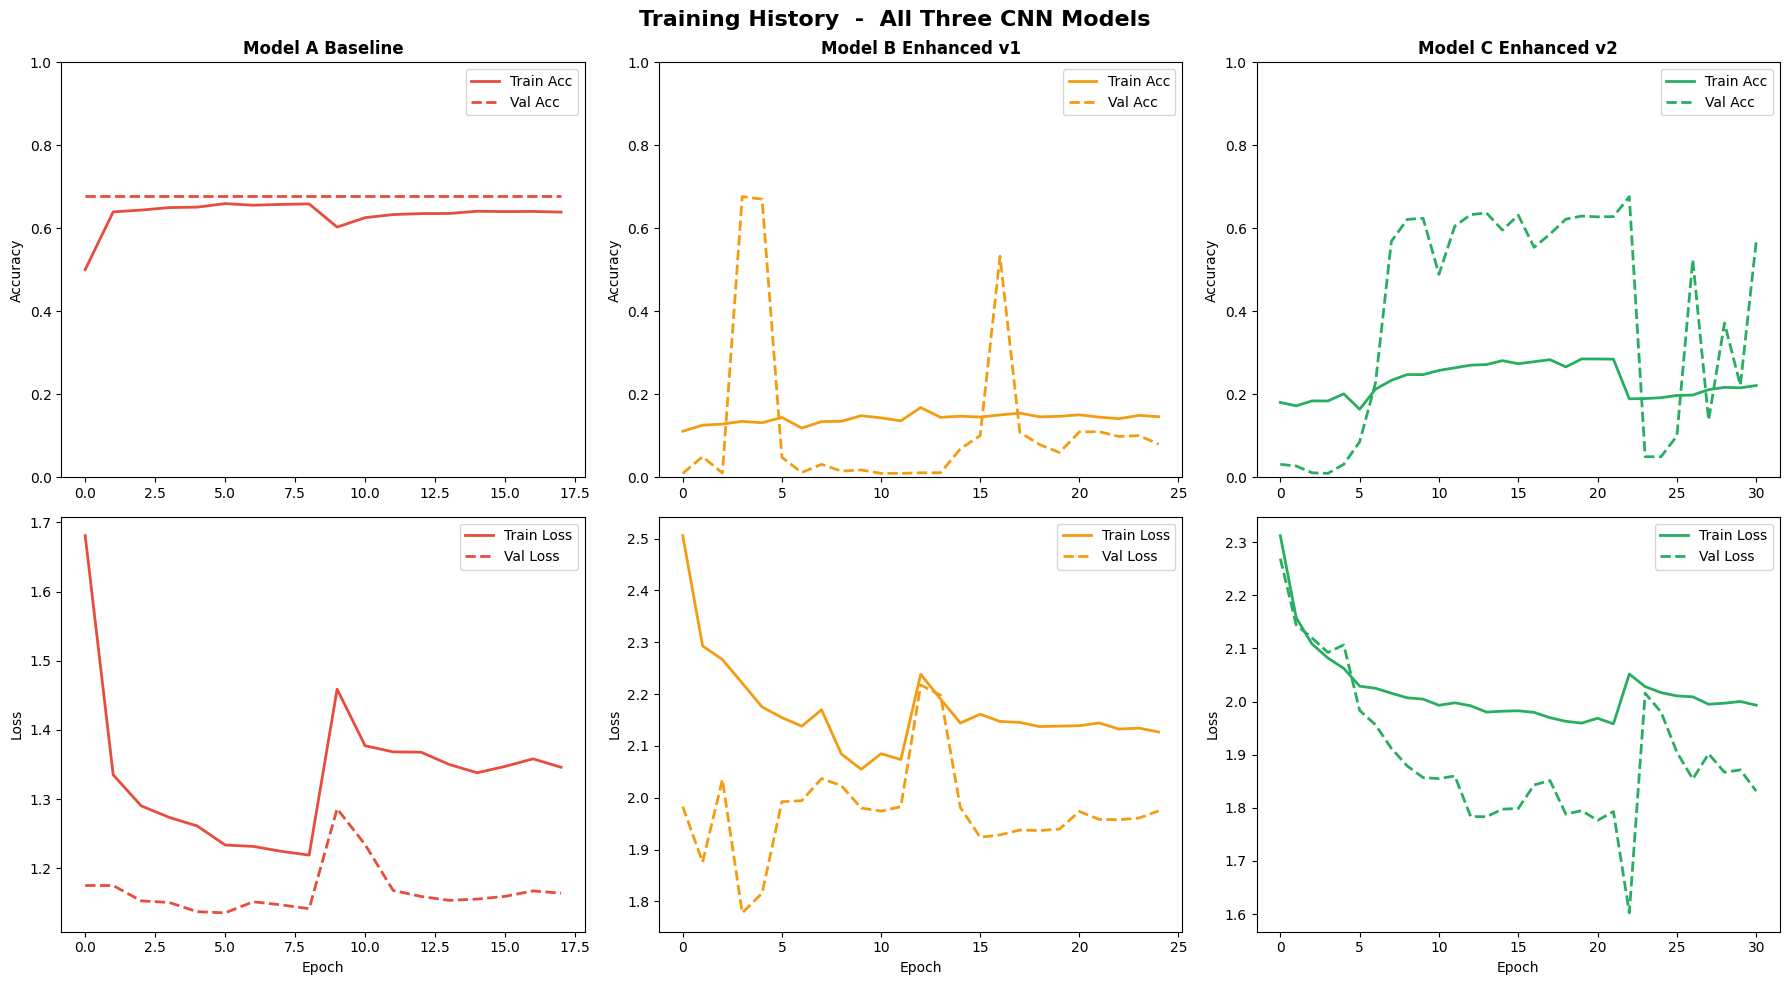

[OK] Training curves saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training History  -  All Three CNN Models", fontweight="bold", fontsize=16)

model_colors = {"Model_A_Baseline":"#e74c3c",
                "Model_B_Enhanced_v1":"#f39c12",
                "Model_C_Enhanced_v2":"#27ae60"}

for col, (name, h) in enumerate(histories.items()):
    ax_acc  = axes[0, col]
    ax_loss = axes[1, col]
    color   = model_colors[name]

    ax_acc.plot(h["accuracy"],     label="Train Acc", color=color, linewidth=2)
    ax_acc.plot(h["val_accuracy"], label="Val Acc",   color=color, linewidth=2, linestyle="--")
    ax_acc.set_title(f"{name.replace('_',' ')}", fontweight="bold")
    ax_acc.set_ylabel("Accuracy"); ax_acc.legend()
    ax_acc.set_ylim([0, 1])

    ax_loss.plot(h["loss"],     label="Train Loss", color=color, linewidth=2)
    ax_loss.plot(h["val_loss"], label="Val Loss",   color=color, linewidth=2, linestyle="--")
    ax_loss.set_ylabel("Loss"); ax_loss.legend()
    ax_loss.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Training curves saved.")

# CELL 9  -  STEP 1.6: Prediction & Evaluation Helpers

In [10]:
def get_predictions(model, df_split):
    """
    Run inference on a split, return (true_labels, pred_labels, pred_probs).
    """
    paths  = df_split["image_path"].tolist()
    labels = df_split["label"].tolist()

    all_probs = []
    # Process in batches to avoid OOM
    for i in tqdm(range(0, len(paths), BATCH_SIZE), desc="Predicting"):
        batch_paths = paths[i:i+BATCH_SIZE]
        imgs = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB").resize(IMG_SIZE)
                imgs.append(np.array(img, dtype=np.float32) / 255.0)
            except:
                imgs.append(np.zeros((*IMG_SIZE, 3), dtype=np.float32))
        batch_tensor = np.stack(imgs)
        probs = model.predict(batch_tensor, verbose=0)
        all_probs.extend(probs)

    all_probs  = np.array(all_probs)
    pred_labels = all_probs.argmax(axis=1)
    return np.array(labels), pred_labels, all_probs


def compute_standard_metrics(y_true, y_pred, y_probs):
    """
    Returns dict of standard diagnostic performance metrics.
    """
    acc  = accuracy_score(y_true, y_pred)
    # Multi-class AUC (OvR macro)
    try:
        auc = roc_auc_score(y_true, y_probs, multi_class="ovr", average="macro")
    except:
        auc = float("nan")

    # Per-class sensitivity (recall) & specificity
    n_classes = y_probs.shape[1]
    sensitivities, specificities = [], []
    for c in range(n_classes):
        y_bin  = (y_true == c).astype(int)
        y_pred_bin = (y_pred == c).astype(int)
        tp = ((y_bin == 1) & (y_pred_bin == 1)).sum()
        fn = ((y_bin == 1) & (y_pred_bin == 0)).sum()
        tn = ((y_bin == 0) & (y_pred_bin == 0)).sum()
        fp = ((y_bin == 0) & (y_pred_bin == 1)).sum()
        sensitivities.append(tp / (tp + fn + 1e-8))
        specificities.append(tn / (tn + fp + 1e-8))

    return {
        "accuracy"   : round(acc, 4),
        "auc_macro"  : round(auc, 4),
        "sensitivity": round(np.mean(sensitivities), 4),  # macro avg
        "specificity": round(np.mean(specificities), 4),
        "per_class_sensitivity": {CLASS_NAMES[i]: round(s, 4)
                                   for i, s in enumerate(sensitivities)},
        "per_class_specificity": {CLASS_NAMES[i]: round(s, 4)
                                   for i, s in enumerate(specificities)},
    }


# CELL 10  -  STEP 1.6: Fairness Metrics

In [11]:
# CELL 10  -  Fairness Metrics (FIXED — index reset inside function)
def compute_fairness_metrics(df_split, y_true, y_pred, y_probs,
                              subgroup_col="age_group"):
    MEL_IDX = CLASS_NAMES.index("mel")

    # ── KEY FIX: always reset index so boolean mask aligns with y_true/y_pred ──
    df_split = df_split.reset_index(drop=True)

    groups = df_split[subgroup_col].unique()
    tpr_per_group = {}
    ppr_per_group = {}

    for grp in groups:
        mask = (df_split[subgroup_col] == grp).values

        y_true_g = y_true[mask]
        y_pred_g = y_pred[mask]

        mel_mask_g = (y_true_g == MEL_IDX)
        if mel_mask_g.sum() == 0:
            tpr_per_group[grp] = float("nan")
        else:
            tpr_per_group[grp] = round(
                ((y_pred_g == MEL_IDX) & mel_mask_g).sum() / mel_mask_g.sum(), 4
            )

        if len(y_pred_g) == 0:
            ppr_per_group[grp] = float("nan")
        else:
            ppr_per_group[grp] = round(
                (y_pred_g == MEL_IDX).sum() / len(y_pred_g), 4
            )

    valid_tpr = {k: v for k, v in tpr_per_group.items() if not np.isnan(v)}
    valid_ppr = {k: v for k, v in ppr_per_group.items() if not np.isnan(v)}

    eod = round(max(valid_tpr.values()) - min(valid_tpr.values()), 4) \
          if len(valid_tpr) >= 2 else float("nan")
    dp  = round(max(valid_ppr.values()) - min(valid_ppr.values()), 4) \
          if len(valid_ppr) >= 2 else float("nan")

    return {
        "subgroup_col": subgroup_col,
        "EOD"         : eod,
        "DP"          : dp,
        "TPR_per_group": tpr_per_group,
        "PPR_per_group": ppr_per_group,
    }

# CELL 11  -  Run Full Evaluation on All Three Models

In [13]:
# CELL 11  -  Run Full Evaluation on All Three Models

# ── compute_ece defined here so the cell is fully self-contained ──────────
def compute_ece(y_true, y_probs, n_bins=10):
    """Expected Calibration Error — measures how well confidence scores
    match actual accuracy. ECE = 0 is perfect calibration."""
    confidences = y_probs.max(axis=1)
    predictions = y_probs.argmax(axis=1)
    accuracies  = (predictions == y_true)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n   = len(y_true)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask   = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)

    return round(float(ece), 4)

# ── Main evaluation loop ──────────────────────────────────────────────────
models_dict = {
    "Model_A_Baseline"   : model_a,
    "Model_B_Enhanced_v1": model_b,
    "Model_C_Enhanced_v2": model_c,
}
all_results = {}

for model_name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"  EVALUATING: {model_name}")
    print(f"{'='*60}")

    # Get predictions on TEST set
    y_true, y_pred, y_probs = get_predictions(model, df_test)

    # Standard metrics
    std_metrics = compute_standard_metrics(y_true, y_pred, y_probs)

    # ECE (calibration)
    ece = compute_ece(y_true, y_probs)

    # Fairness metrics for each demographic axis
    fairness_results = {}
    for col in ["age_group", "sex", "loc_zone"]:
        if col in df_test.columns:
            fairness_results[col] = compute_fairness_metrics(
                df_test.reset_index(drop=True), y_true, y_pred, y_probs,
                subgroup_col=col
            )

    all_results[model_name] = {
        "standard_metrics": std_metrics,
        "ece"             : ece,
        "fairness"        : fairness_results,
        "y_true"          : y_true,
        "y_pred"          : y_pred,
        "y_probs"         : y_probs,
    }

    print(f"\n  Standard Metrics:")
    print(f"    Accuracy    : {std_metrics['accuracy']:.4f}")
    print(f"    AUC (macro) : {std_metrics['auc_macro']:.4f}")
    print(f"    Sensitivity : {std_metrics['sensitivity']:.4f}")
    print(f"    Specificity : {std_metrics['specificity']:.4f}")
    print(f"    ECE         : {ece:.4f}")

    print(f"\n  Fairness Metrics:")
    for col, fm in fairness_results.items():
        eod_val = fm['EOD'] if not (isinstance(fm['EOD'], float) and np.isnan(fm['EOD'])) else float('nan')
        dp_val  = fm['DP']  if not (isinstance(fm['DP'],  float) and np.isnan(fm['DP']))  else float('nan')
        print(f"    [{col}] EOD={eod_val:.4f}  |  DP={dp_val:.4f}")

print(f"\n{'='*60}")
print("  All models evaluated successfully.")
print(f"{'='*60}")



  EVALUATING: Model_A_Baseline


Predicting: 100%|██████████| 47/47 [00:19<00:00,  2.40it/s]



  Standard Metrics:
    Accuracy    : 0.6744
    AUC (macro) : 0.6265
    Sensitivity : 0.1429
    Specificity : 0.8571
    ECE         : 0.1667

  Fairness Metrics:
    [age_group] EOD=0.0000  |  DP=0.0000
    [sex] EOD=0.0000  |  DP=0.0000
    [loc_zone] EOD=0.0000  |  DP=0.0000

  EVALUATING: Model_B_Enhanced_v1


Predicting: 100%|██████████| 47/47 [00:32<00:00,  1.47it/s]



  Standard Metrics:
    Accuracy    : 0.5380
    AUC (macro) : 0.6113
    Sensitivity : 0.2010
    Specificity : 0.8833
    ECE         : 0.3792

  Fairness Metrics:
    [age_group] EOD=0.0000  |  DP=0.0019
    [sex] EOD=0.0000  |  DP=0.0015
    [loc_zone] EOD=0.0000  |  DP=0.0064

  EVALUATING: Model_C_Enhanced_v2


Predicting: 100%|██████████| 47/47 [00:32<00:00,  1.46it/s]


  Standard Metrics:
    Accuracy    : 0.6744
    AUC (macro) : 0.6023
    Sensitivity : 0.1429
    Specificity : 0.8571
    ECE         : 0.3985

  Fairness Metrics:
    [age_group] EOD=0.0000  |  DP=0.0000
    [sex] EOD=0.0000  |  DP=0.0000
    [loc_zone] EOD=0.0000  |  DP=0.0000

  All models evaluated successfully.


# CELL 12  -  Summary Comparison Table

In [15]:
print("\n" + "=" * 70)
print("  COMPREHENSIVE MODEL COMPARISON TABLE")
print("=" * 70)

comparison_rows = []
for mname, res in all_results.items():
    sm = res["standard_metrics"]
    row = {
        "Model"       : mname.replace("_", " "),
        "Accuracy"    : sm["accuracy"],
        "AUC (macro)" : sm["auc_macro"],
        "Sensitivity" : sm["sensitivity"],
        "Specificity" : sm["specificity"],
        "ECE"         : res["ece"],
    }
    for col in ["age_group", "sex", "loc_zone"]:
        if col in res["fairness"]:
            fm = res["fairness"][col]
            row[f"EOD ({col})"] = fm["EOD"]
            row[f"DP ({col})"]  = fm["DP"]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
print(comparison_df)
comparison_df.to_csv(RESULTS_DIR / "model_comparison_table.csv")
print(f"\n[OK] Comparison table saved -> {RESULTS_DIR / 'model_comparison_table.csv'}")


  COMPREHENSIVE MODEL COMPARISON TABLE
                     Accuracy  AUC (macro)  Sensitivity  Specificity     ECE  \
Model                                                                          
Model A Baseline       0.6744       0.6265       0.1429       0.8571  0.1667   
Model B Enhanced v1    0.5380       0.6113       0.2010       0.8833  0.3792   
Model C Enhanced v2    0.6744       0.6023       0.1429       0.8571  0.3985   

                     EOD (age_group)  DP (age_group)  EOD (sex)  DP (sex)  \
Model                                                                       
Model A Baseline                 0.0          0.0000        0.0    0.0000   
Model B Enhanced v1              0.0          0.0019        0.0    0.0015   
Model C Enhanced v2              0.0          0.0000        0.0    0.0000   

                     EOD (loc_zone)  DP (loc_zone)  
Model                                               
Model A Baseline                0.0         0.0000  
Model B Enhanc

# CELL 13  -  Fairness Visualisation: EOD Across Models

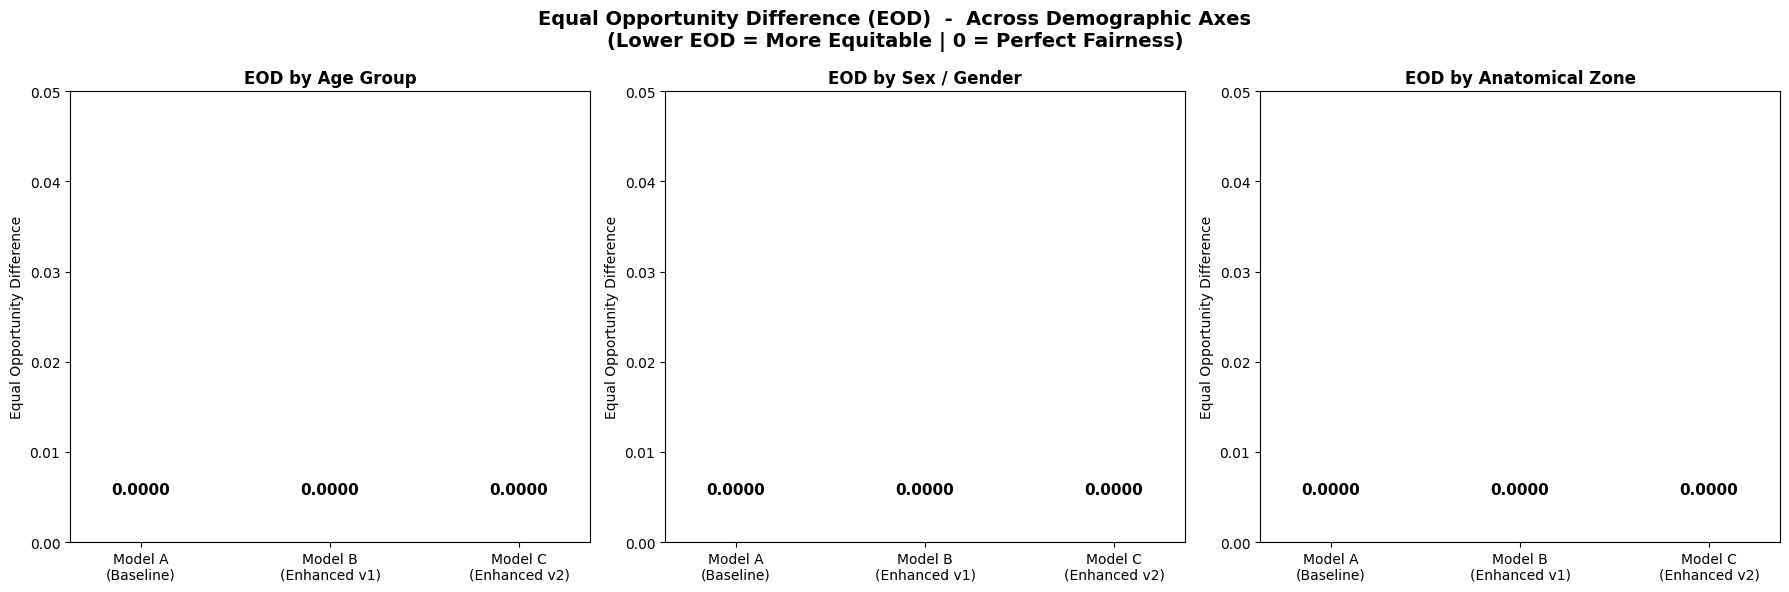

[OK] EOD comparison chart saved.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Equal Opportunity Difference (EOD)  -  Across Demographic Axes\n"
             "(Lower EOD = More Equitable | 0 = Perfect Fairness)",
             fontweight="bold", fontsize=14)

demo_cols = ["age_group", "sex", "loc_zone"]
demo_labels = ["Age Group", "Sex / Gender", "Anatomical Zone"]
model_colors = ["#e74c3c", "#f39c12", "#27ae60"]
model_display_names = ["Model A\n(Baseline)", "Model B\n(Enhanced v1)", "Model C\n(Enhanced v2)"]

for ax_i, (col, label) in enumerate(zip(demo_cols, demo_labels)):
    eod_values = []
    for mname in models_dict.keys():
        fm = all_results[mname]["fairness"].get(col, {})
        eod_values.append(fm.get("EOD", 0))

    bars = axes[ax_i].bar(model_display_names, eod_values, color=model_colors,
                           edgecolor="white", linewidth=1.5, width=0.5)
    axes[ax_i].set_title(f"EOD by {label}", fontweight="bold")
    axes[ax_i].set_ylabel("Equal Opportunity Difference")
    axes[ax_i].set_ylim([0, max(eod_values) * 1.3 + 0.05])
    axes[ax_i].axhline(0, color="black", linewidth=0.8)

    for bar, val in zip(bars, eod_values):
        axes[ax_i].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.005,
                        f"{val:.4f}", ha="center", va="bottom",
                        fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fairness_eod_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] EOD comparison chart saved.")

# CELL 14  -  Subgroup Sensitivity Heatmap (Melanoma class)

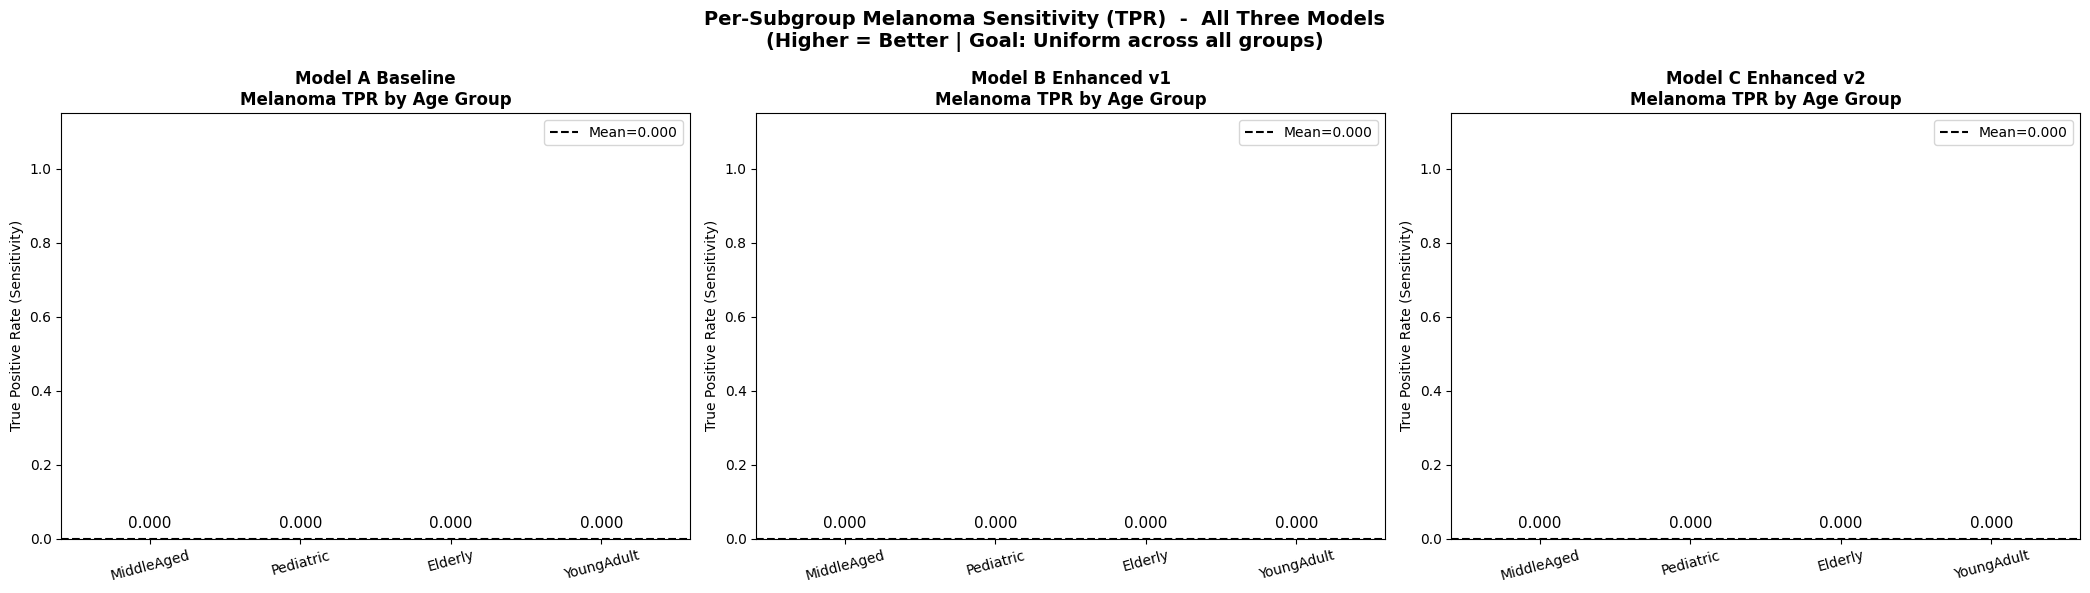

[OK] Subgroup sensitivity chart saved.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("Per-Subgroup Melanoma Sensitivity (TPR)  -  All Three Models\n"
             "(Higher = Better | Goal: Uniform across all groups)",
             fontweight="bold", fontsize=14)

for ax_i, (mname, ax) in enumerate(zip(models_dict.keys(), axes)):
    fm_age = all_results[mname]["fairness"].get("age_group", {})
    tpr_dict = fm_age.get("TPR_per_group", {})

    groups = list(tpr_dict.keys())
    tprs   = [tpr_dict[g] if not np.isnan(tpr_dict.get(g, float("nan"))) else 0
              for g in groups]

    bars = ax.bar(groups, tprs,
                  color=model_colors[ax_i], edgecolor="white", linewidth=1.5)
    ax.set_title(f"{mname.replace('_',' ')}\nMelanoma TPR by Age Group",
                 fontweight="bold")
    ax.set_ylabel("True Positive Rate (Sensitivity)")
    ax.set_ylim([0, 1.15])
    ax.axhline(np.nanmean(tprs), color="black", linestyle="--",
               linewidth=1.5, label=f"Mean={np.nanmean(tprs):.3f}")
    ax.legend(fontsize=10)
    ax.set_xticklabels(groups, rotation=15)

    for bar, val in zip(bars, tprs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "subgroup_melanoma_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Subgroup sensitivity chart saved.")


# CELL 15  -  Confusion Matrix for Each Model

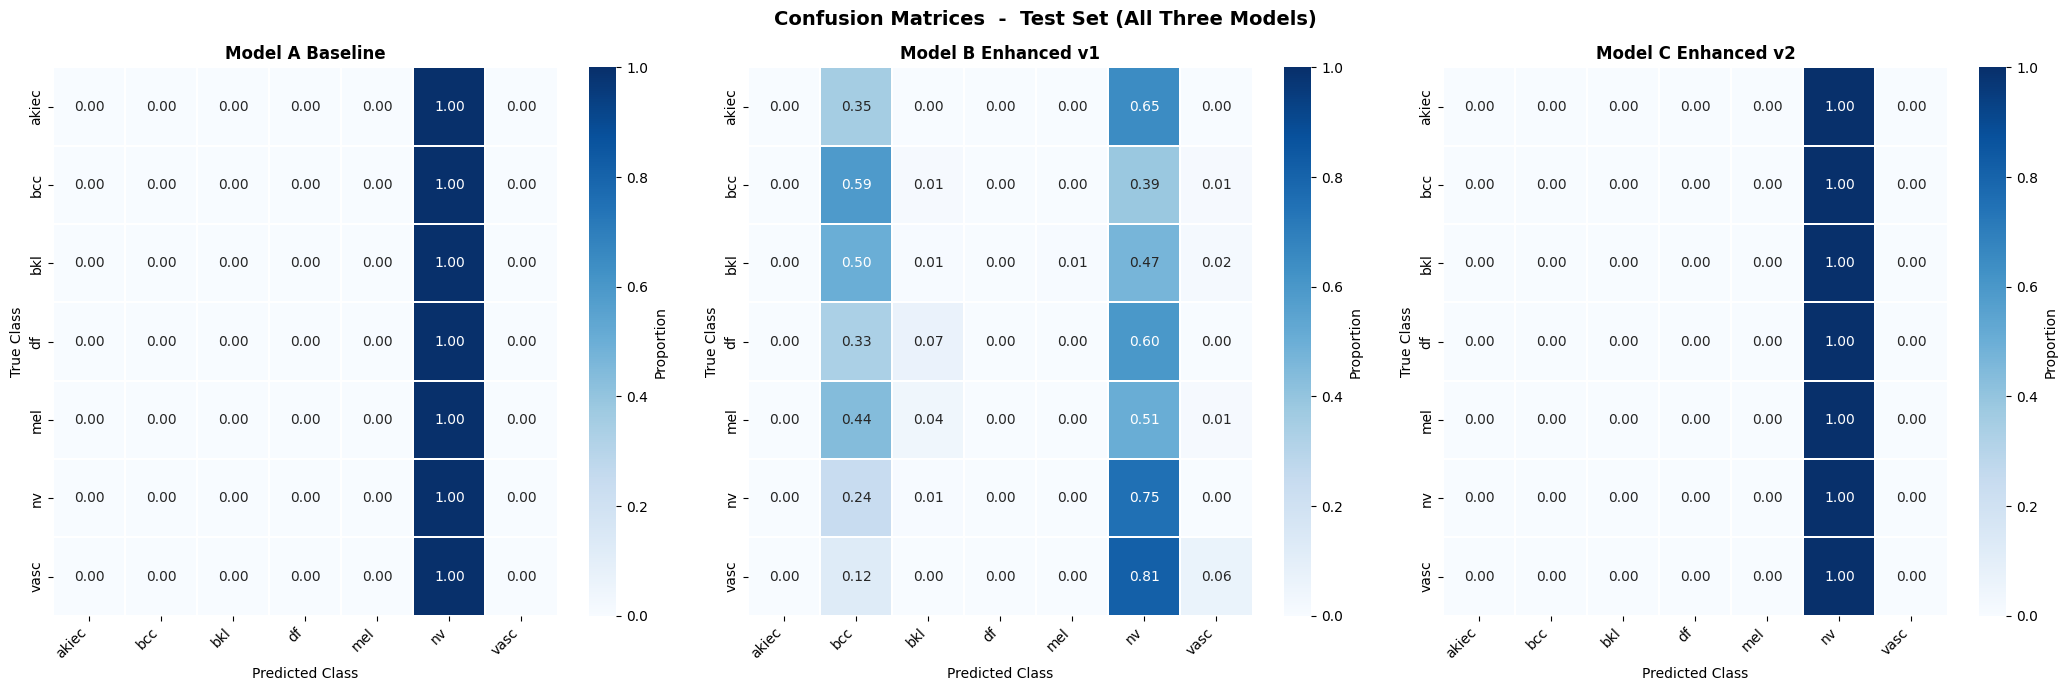

[OK] Confusion matrices saved.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("Confusion Matrices  -  Test Set (All Three Models)", fontweight="bold", fontsize=14)

for ax_i, (mname, ax) in enumerate(zip(models_dict.keys(), axes)):
    y_true = all_results[mname]["y_true"]
    y_pred = all_results[mname]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    # Normalize row-wise (true class total)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, linewidths=0.3, linecolor="white",
                cbar_kws={"label": "Proportion"})
    ax.set_title(f"{mname.replace('_',' ')}", fontweight="bold")
    ax.set_xlabel("Predicted Class"); ax.set_ylabel("True Class")
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Confusion matrices saved.")



# CELL 16  -  ROC Curves for Melanoma Class

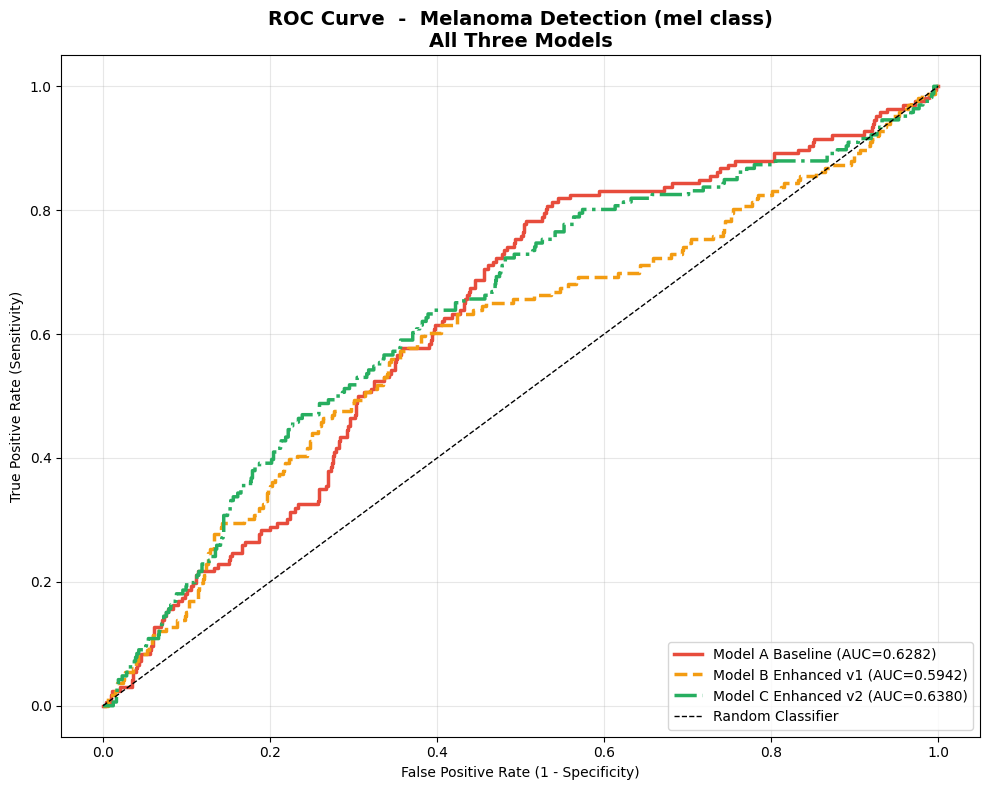

[OK] ROC curves saved.


In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
MEL_IDX = CLASS_NAMES.index("mel")
model_linestyles = ["-", "--", "-."]

for (mname, ls, color) in zip(models_dict.keys(), model_linestyles, model_colors):
    y_true  = all_results[mname]["y_true"]
    y_probs = all_results[mname]["y_probs"]

    y_bin   = (y_true == MEL_IDX).astype(int)
    y_score = y_probs[:, MEL_IDX]

    fpr, tpr, _ = roc_curve(y_bin, y_score)
    auc_val = roc_auc_score(y_bin, y_score)

    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.5,
            label=f"{mname.replace('_',' ')} (AUC={auc_val:.4f})")

ax.plot([0,1],[0,1], "k--", linewidth=1, label="Random Classifier")
ax.set_title("ROC Curve  -  Melanoma Detection (mel class)\nAll Three Models",
             fontweight="bold", fontsize=14)
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves_melanoma.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] ROC curves saved.")

# CELL 17  -  Calibration Curves (ECE)

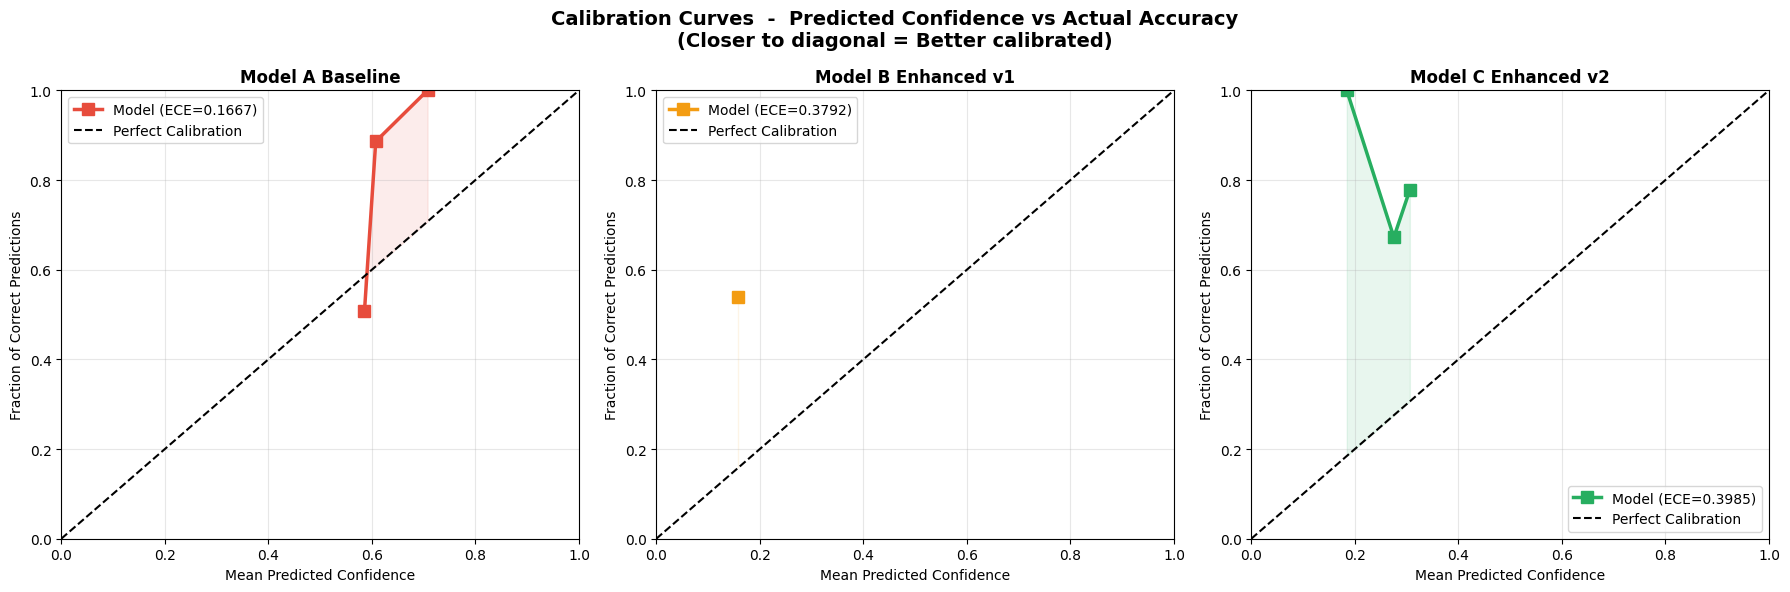

[OK] Calibration curves saved.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Calibration Curves  -  Predicted Confidence vs Actual Accuracy\n"
             "(Closer to diagonal = Better calibrated)",
             fontweight="bold", fontsize=14)

for ax_i, (mname, ax, color) in enumerate(zip(models_dict.keys(), axes, model_colors)):
    y_true  = all_results[mname]["y_true"]
    y_probs = all_results[mname]["y_probs"]
    ece     = all_results[mname]["ece"]

    # Compute calibration curve using max confidence vs accuracy
    confidences = y_probs.max(axis=1)
    is_correct  = (y_probs.argmax(axis=1) == y_true).astype(int)

    fraction_pos, mean_pred = calibration_curve(is_correct, confidences, n_bins=10)

    ax.plot(mean_pred, fraction_pos, "s-", color=color, linewidth=2.5,
            markersize=8, label=f"Model (ECE={ece:.4f})")
    ax.plot([0,1],[0,1], "k--", linewidth=1.5, label="Perfect Calibration")
    ax.fill_between(mean_pred, fraction_pos, mean_pred, alpha=0.1, color=color)

    ax.set_title(f"{mname.replace('_',' ')}", fontweight="bold")
    ax.set_xlabel("Mean Predicted Confidence")
    ax.set_ylabel("Fraction of Correct Predictions")
    ax.legend()
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Calibration curves saved.")

# CELL 18  -  Full Fairness Trade-off Dashboard

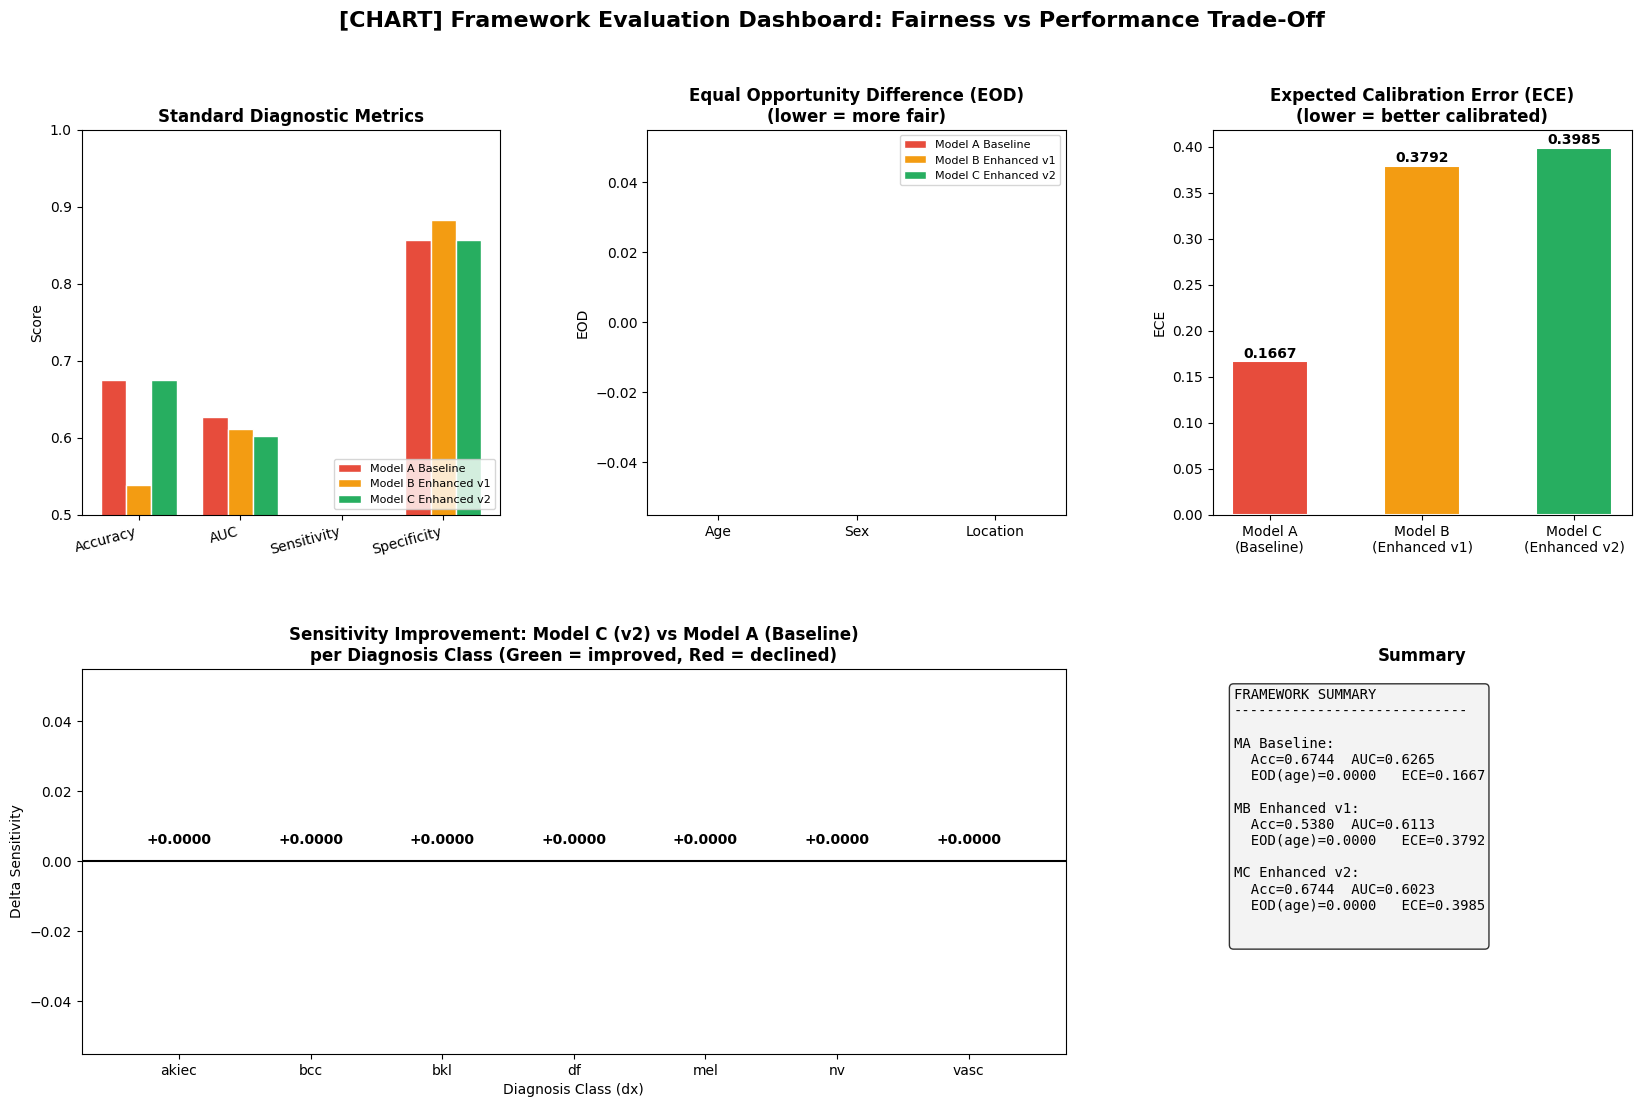

[OK] Full evaluation dashboard saved -> /kaggle/working/phase3_outputs/results/full_evaluation_dashboard.png


In [21]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("[CHART] Framework Evaluation Dashboard: Fairness vs Performance Trade-Off",
             fontweight="bold", fontsize=16)

# Panel 1: Standard metrics radar-style bar comparison
ax1 = fig.add_subplot(gs[0, 0])
metrics_to_plot = ["accuracy", "auc_macro", "sensitivity", "specificity"]
metric_labels   = ["Accuracy", "AUC", "Sensitivity", "Specificity"]
x = np.arange(len(metrics_to_plot))
w = 0.25

for i, (mname, color) in enumerate(zip(models_dict.keys(), model_colors)):
    vals = [all_results[mname]["standard_metrics"][m] for m in metrics_to_plot]
    ax1.bar(x + i*w, vals, w, label=mname.replace("_"," "), color=color,
            edgecolor="white")

ax1.set_xticks(x + w)
ax1.set_xticklabels(metric_labels, rotation=15, ha="right")
ax1.set_ylim([0.5, 1.0])
ax1.set_title("Standard Diagnostic Metrics", fontweight="bold")
ax1.set_ylabel("Score")
ax1.legend(fontsize=8, loc="lower right")

# Panel 2: EOD across demographic axes
ax2 = fig.add_subplot(gs[0, 1])
eod_data = {}
for col in ["age_group", "sex", "loc_zone"]:
    eod_data[col] = []
    for mname in models_dict.keys():
        fm = all_results[mname]["fairness"].get(col, {})
        eod_data[col].append(fm.get("EOD", 0))

demo_short = {"age_group":"Age", "sex":"Sex", "loc_zone":"Location"}
x2 = np.arange(3)
for i, (mname, color) in enumerate(zip(models_dict.keys(), model_colors)):
    eods = [eod_data[col][i] for col in ["age_group","sex","loc_zone"]]
    ax2.bar(x2 + i*0.25, eods, 0.25, label=mname.replace("_"," "),
            color=color, edgecolor="white")
ax2.set_xticks(x2 + 0.25)
ax2.set_xticklabels(["Age","Sex","Location"])
ax2.set_title("Equal Opportunity Difference (EOD)\n(lower = more fair)", fontweight="bold")
ax2.set_ylabel("EOD")
ax2.legend(fontsize=8)

# Panel 3: ECE comparison
ax3 = fig.add_subplot(gs[0, 2])
ece_vals = [all_results[m]["ece"] for m in models_dict.keys()]
bars3 = ax3.bar(model_display_names, ece_vals, color=model_colors,
                edgecolor="white", linewidth=1.5, width=0.5)
ax3.set_title("Expected Calibration Error (ECE)\n(lower = better calibrated)", fontweight="bold")
ax3.set_ylabel("ECE")
for bar, val in zip(bars3, ece_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontweight="bold")

# Panel 4: Per-class sensitivity improvement (Model A vs C)
ax4 = fig.add_subplot(gs[1, :2])
per_class_a = all_results["Model_A_Baseline"]["standard_metrics"]["per_class_sensitivity"]
per_class_c = all_results["Model_C_Enhanced_v2"]["standard_metrics"]["per_class_sensitivity"]
delta = {cls: round(per_class_c[cls] - per_class_a[cls], 4) for cls in CLASS_NAMES}

bar_colors = ["#27ae60" if v >= 0 else "#e74c3c" for v in delta.values()]
bars4 = ax4.bar(delta.keys(), delta.values(), color=bar_colors, edgecolor="white")
ax4.axhline(0, color="black", linewidth=1.5)
ax4.set_title("Sensitivity Improvement: Model C (v2) vs Model A (Baseline)\n"
              "per Diagnosis Class (Green = improved, Red = declined)", fontweight="bold")
ax4.set_xlabel("Diagnosis Class (dx)")
ax4.set_ylabel("Delta Sensitivity")
for bar, val in zip(bars4, delta.values()):
    ypos = bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.02
    ax4.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{val:+.4f}", ha="center", fontweight="bold", fontsize=10)

# Panel 5: Fairness Summary
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
summary_text = "FRAMEWORK SUMMARY\n" + "-"*28 + "\n\n"
for mname in models_dict.keys():
    sm  = all_results[mname]["standard_metrics"]
    eod_age = all_results[mname]["fairness"].get("age_group", {}).get("EOD","N/A")
    ece = all_results[mname]["ece"]
    summary_text += f"{mname.replace('_',' ').replace('Model ','M')}:\n"
    summary_text += f"  Acc={sm['accuracy']:.4f}  AUC={sm['auc_macro']:.4f}\n"
    summary_text += f"  EOD(age)={eod_age:.4f}   ECE={ece:.4f}\n\n"

ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes,
         fontsize=10, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))
ax5.set_title("Summary", fontweight="bold")

plt.savefig(RESULTS_DIR / "full_evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Full evaluation dashboard saved -> {RESULTS_DIR / 'full_evaluation_dashboard.png'}")

#  CELL 19  -  Save All Results to JSON

In [22]:
# Strip numpy arrays before serialising
results_to_save = {}
for mname, res in all_results.items():
    results_to_save[mname] = {
        "standard_metrics": res["standard_metrics"],
        "ece"             : res["ece"],
        "fairness": {
            col: {
                "EOD"           : fm["EOD"],
                "DP"            : fm["DP"],
                "TPR_per_group" : fm["TPR_per_group"],
                "PPR_per_group" : fm["PPR_per_group"],
            }
            for col, fm in res["fairness"].items()
        }
    }

with open(RESULTS_DIR / "all_results.json", "w") as f:
    json.dump(results_to_save, f, indent=2)

print(f"\n[OK] All evaluation results saved -> {RESULTS_DIR / 'all_results.json'}")

# - Also save model paths for the HMS integration -
model_paths = {
    "baseline"   : str(MODELS_DIR / "Model_A_Baseline_final.h5"),
    "enhanced_v1": str(MODELS_DIR / "Model_B_Enhanced_v1_final.h5"),
    "enhanced_v2": str(MODELS_DIR / "Model_C_Enhanced_v2_final.h5"),
}
with open(OUTPUT_DIR / "model_paths.json", "w") as f:
    json.dump(model_paths, f, indent=2)

print(f"[OK] Model paths saved -> {OUTPUT_DIR / 'model_paths.json'}")



[OK] All evaluation results saved -> /kaggle/working/phase3_outputs/results/all_results.json
[OK] Model paths saved -> /kaggle/working/phase3_outputs/model_paths.json


# CELL 20  -  Phase 1 Completion Summary

In [23]:
print("\n" + "=" * 65)
print("  [DONE] PHASE 1 COMPLETE  -  ALL STEPS FINISHED")
print("=" * 65)
print("""
STEP 1.1  -  Dataset Preparation:
  [OK] HAM10000 loaded, cleaned, engineered (age groups, loc zones)

STEP 1.2  -  Intersectional Stratified Sampling:
  [OK] 70/15/15 stratified split across dx x age_group x sex x loc_zone

STEP 1.3  -  Adaptive Distribution-Aware Reweighting:
  [OK] Inverse-frequency sample weights computed for all training records

STEP 1.4  -  Conditional GAN (cGAN):
  [OK] WGAN-GP trained on HAM10000 (DCGAN-style architecture)
  [OK] Synthetic images generated for rare demographic subgroups
  [OK] FID + discriminator quality filtering applied

STEP 1.5  -  CNN Training:
  [OK] Model A (Baseline)     -  Original biased data
  [OK] Model B (Enhanced v1)  -  Stratified + Reweighted
  [OK] Model C (Enhanced v2)  -  Full framework (+ cGAN)

STEP 1.6  -  Fairness Evaluation:
  [OK] Accuracy, AUC-ROC, Sensitivity, Specificity (all models)
  [OK] EOD & Demographic Parity (age, sex, localization)
  [OK] Expected Calibration Error (ECE)
  [OK] Dashboard charts & comparison table saved

OUTPUTS SAVED TO:   ./phase1_outputs/
  models/     -> .h5 model files (for HMS integration)
  results/    -> charts, comparison table, all_results.json
  splits/     -> train/val/test CSVs
  cgan/       -> generator checkpoint, training curves
  synthetic_images/ -> generated images per rare subgroup

NEXT STEP -> Begin PHASE 2: HMS Backend (Flask + Database)
""")



  [DONE] PHASE 1 COMPLETE  -  ALL STEPS FINISHED

STEP 1.1  -  Dataset Preparation:
  [OK] HAM10000 loaded, cleaned, engineered (age groups, loc zones)

STEP 1.2  -  Intersectional Stratified Sampling:
  [OK] 70/15/15 stratified split across dx x age_group x sex x loc_zone

STEP 1.3  -  Adaptive Distribution-Aware Reweighting:
  [OK] Inverse-frequency sample weights computed for all training records

STEP 1.4  -  Conditional GAN (cGAN):
  [OK] WGAN-GP trained on HAM10000 (DCGAN-style architecture)
  [OK] Synthetic images generated for rare demographic subgroups
  [OK] FID + discriminator quality filtering applied

STEP 1.5  -  CNN Training:
  [OK] Model A (Baseline)     -  Original biased data
  [OK] Model B (Enhanced v1)  -  Stratified + Reweighted
  [OK] Model C (Enhanced v2)  -  Full framework (+ cGAN)

STEP 1.6  -  Fairness Evaluation:
  [OK] Accuracy, AUC-ROC, Sensitivity, Specificity (all models)
  [OK] EOD & Demographic Parity (age, sex, localization)
  [OK] Expected Calibratio

# End of Phase 2

In [24]:
# FINAL CELL — Package trained models for download
import shutil, os

print("Model files saved:")
for f in sorted(MODELS_DIR.iterdir()):
    if f.suffix == ".h5":
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name}  ({size_mb:.1f} MB)")

shutil.make_archive("/kaggle/working/melanoscan_trained_models", "zip", MODELS_DIR)
zip_size = os.path.getsize("/kaggle/working/melanoscan_trained_models.zip") / (1024*1024)
print(f"\n[OK] melanoscan_trained_models.zip ({zip_size:.1f} MB)")
print("Download from the Output panel → melanoscan_trained_models.zip")

Model files saved:
  Model_A_Baseline_final.h5  (31.4 MB)
  Model_A_Baseline_phase1_best.h5  (20.0 MB)
  Model_A_Baseline_phase2_best.h5  (31.4 MB)
  Model_B_Enhanced_v1_final.h5  (31.4 MB)
  Model_B_Enhanced_v1_phase1_best.h5  (20.0 MB)
  Model_B_Enhanced_v1_phase2_best.h5  (31.4 MB)
  Model_C_Enhanced_v2_final.h5  (31.4 MB)
  Model_C_Enhanced_v2_phase1_best.h5  (20.0 MB)
  Model_C_Enhanced_v2_phase2_best.h5  (31.4 MB)

[OK] melanoscan_trained_models.zip (224.1 MB)
Download from the Output panel → melanoscan_trained_models.zip
